<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_Word.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# read datasets
word_df = pd.read_csv("/content/Word_Top10_Features.csv")


---

### Word Documents

In [ ]:
word_df.describe()

,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,label
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000
mean,13.704600,1.49870,0.500150,0.499700,0.987200,6.355623,7.645050,5.803250,1.350982e+05,6.567700,0.500000
std,14.383768,1.49917,0.500012,0.500012,1.010142,1.039991,6.397172,5.172454,7.311419e+05,4.577233,0.500013
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,5.450493,0.000000,0.000000,3.842500e+04,0.000000,0.000000
50%,5.500000,1.00000,1.000000,0.000000,0.000000,6.116101,4.000000,2.000000,1.305685e+05,9.000000,0.500000
75%,29.000000,3.00000,1.000000,1.000000,2.000000,7.397829,14.000000,11.000000,1.978658e+05,10.000000,1.000000
max,100.000000,3.00000,1.000000,1.000000,6.000000,7.677271,30.000000,28.000000,5.959293e+07,11.000000,1.000000


In [ ]:
word_df.shape

(20000, 12)

In [ ]:
print(list(word_df.columns))

['file_name', 'ole_object_count', 'ole_object_type_count', 'macro_present', 'dde_present', 'vba_keywords_count', 'entropy', 'struct_ContentType', 'struct_PartName', 'file_size', 'struct_pos', 'label']


In [ ]:
word_df.head()

,file_name,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,label
0,benign_000000,0,0,0,1,0,6.826819,12,10,27585,11,0
1,benign_000001,0,0,0,1,0,7.389457,14,11,36658,10,0
2,benign_000002,0,0,0,1,0,6.850923,12,10,28887,11,0
3,benign_000003,0,0,0,1,0,7.408635,14,11,39295,10,0
4,benign_000004,0,0,0,1,0,7.388929,14,11,36659,10,0


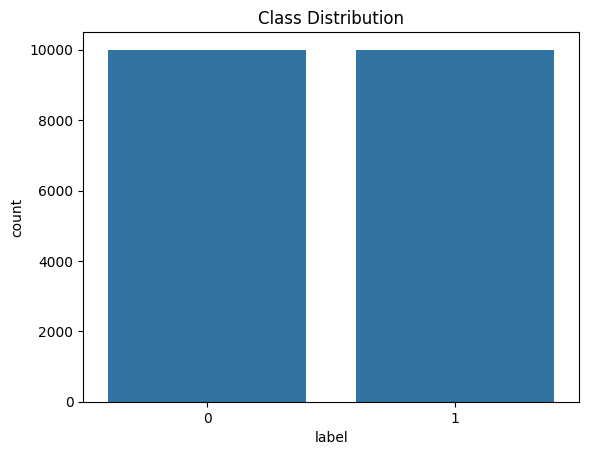

In [ ]:
# verify that the dataset is balanced (50% bengin, 50% malicious)

sns.countplot(data=word_df, x="label")
plt.title("Class Distribution")
plt.show()

In [ ]:
benign_count = (word_df["label"] == 0).sum()
malicious_count = (word_df["label"] == 1).sum()

print("Benign:", benign_count)
print("Malicious:", malicious_count)

Benign: 10000
Malicious: 10000


<Axes: >

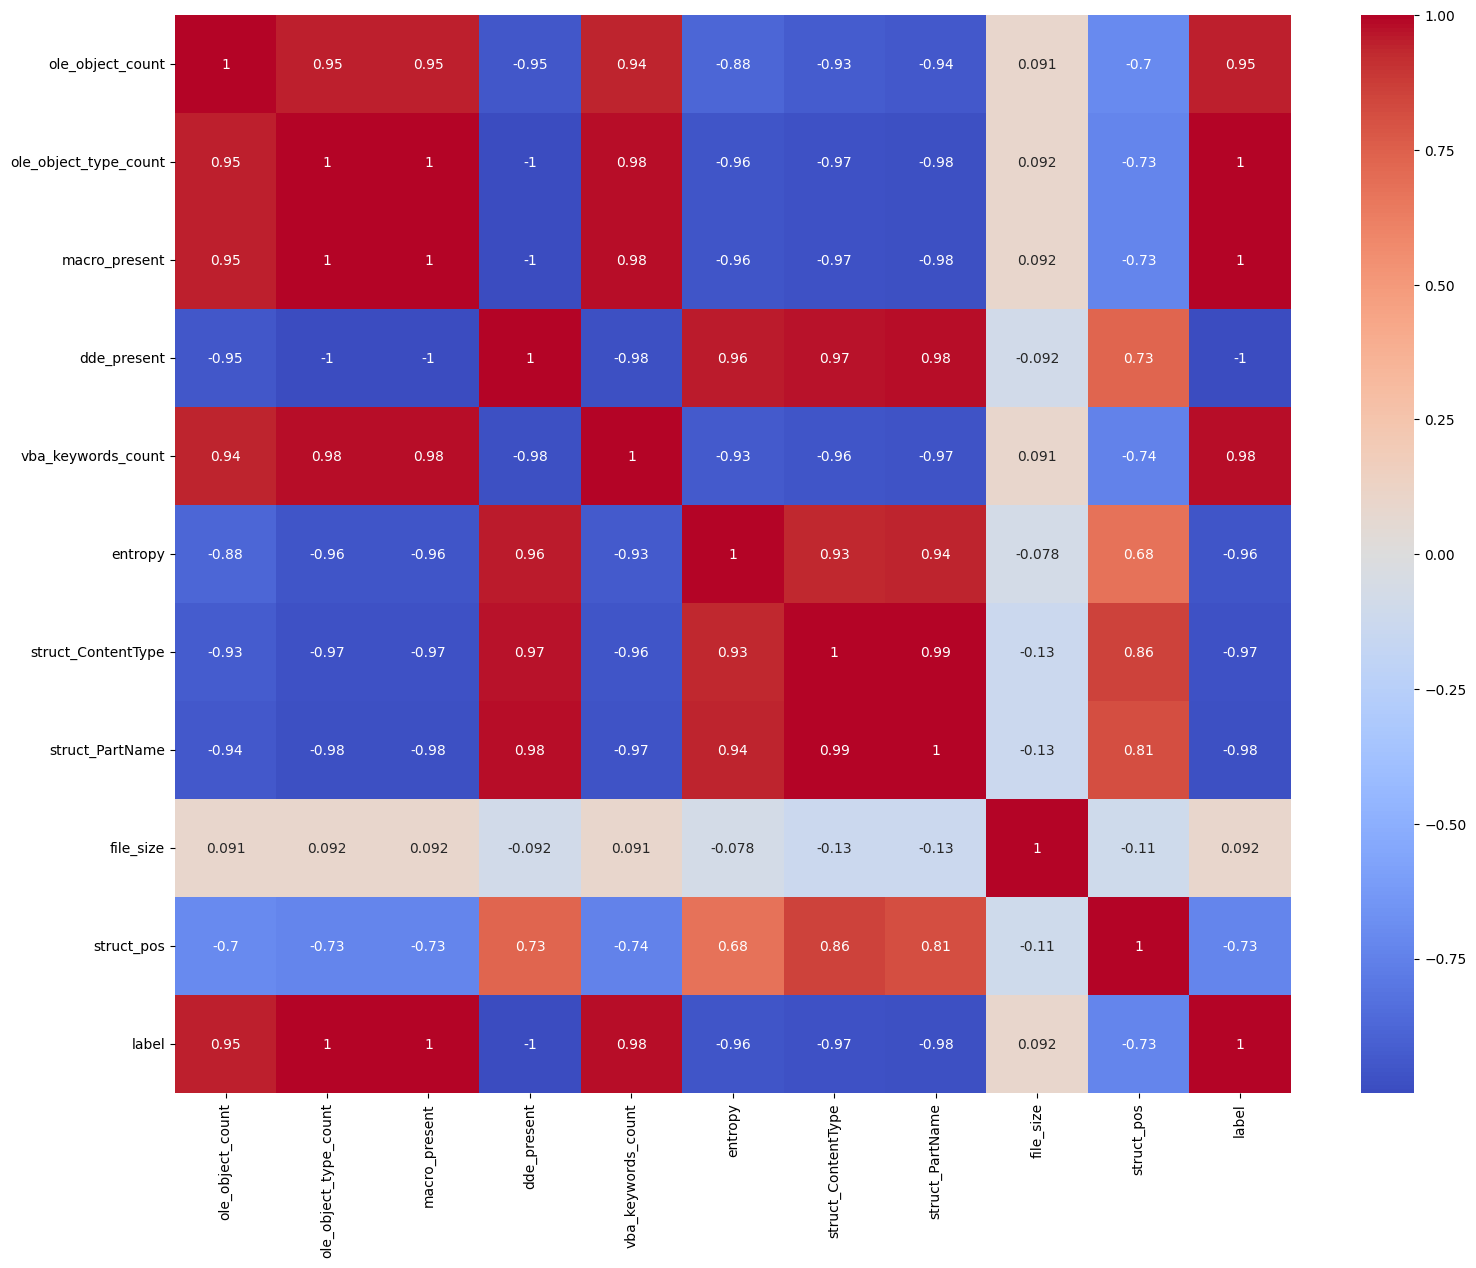

In [ ]:
# Correlation Heatmap (all features)

plt.figure(figsize=(18, 14))
corr = word_df.drop(columns="file_name").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

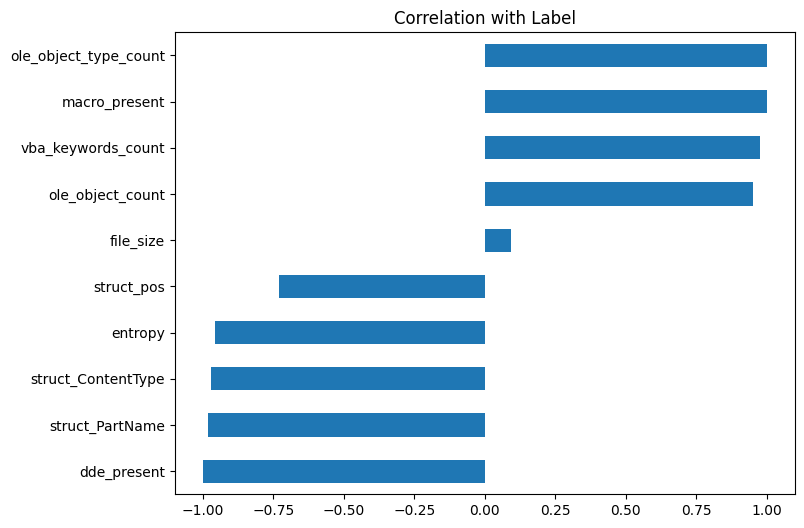

In [ ]:
# Correlation Heatmap for Label

corr = word_df.drop(columns="file_name").corr()["label"].drop('label')

corr.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Label")
plt.show()

# Note:
# (+) correlation → associated with malicious files.
# (-) correlation → associated with benign files.

**Word Dataset Observations**
- Samples are sorted (bengin then malicious) with file names
- 12 columns (10 features + file name col + label col)
- Dataset is balanced (50% bengin, 50% malicious)

Reproduce the Baseline

In [ ]:
X = word_df.drop(columns=['file_name', 'label'])
y = word_df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y
)

In [ ]:
model_word= DecisionTreeClassifier (random_state=42)
model_word.fit(X_train, y_train)

y_pred_dt = model_word.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct prediction", correct)

Correct prediction 5999


In [ ]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt,average='macro')
recall = recall_score(y_test, y_pred_dt,average='macro')
f1 = f1_score(y_test, y_pred_dt,average='macro')
print(f"accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

accuracy: 0.9998
precision: 0.9998
recall: 0.9998
F1-score: 0.9998


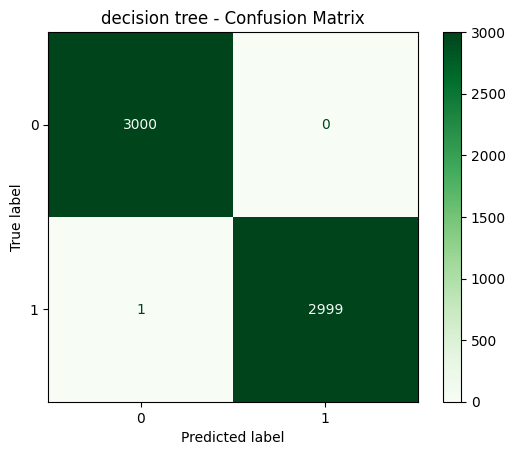

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("decision tree - Confusion Matrix")
plt.show()

In [ ]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)
y_pred_xg = model_xg.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("correct prediction", correct)

correct prediction 6000


In [ ]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg,average='macro')
recall = recall_score(y_test, y_pred_xg,average='macro')
f1 = f1_score(y_test, y_pred_xg,average='macro')

print(f"accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

accuracy: 1.0000
precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


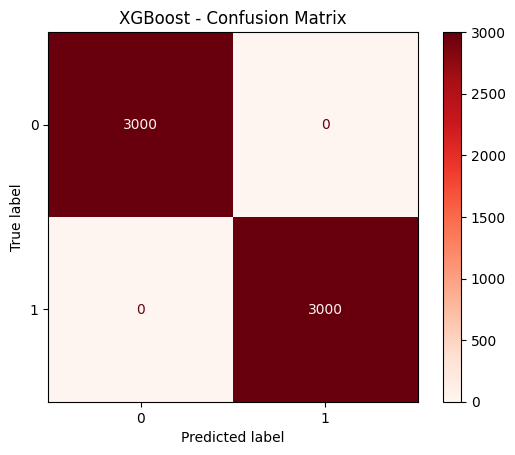

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("correct prediction:", correct)

correct prediction: 6000


In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf,average='macro')
recall = recall_score(y_test, y_pred_rf,average='macro')
f1 = f1_score(y_test, y_pred_rf,average='macro')

print(f"accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

accuracy: 1.0000
precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


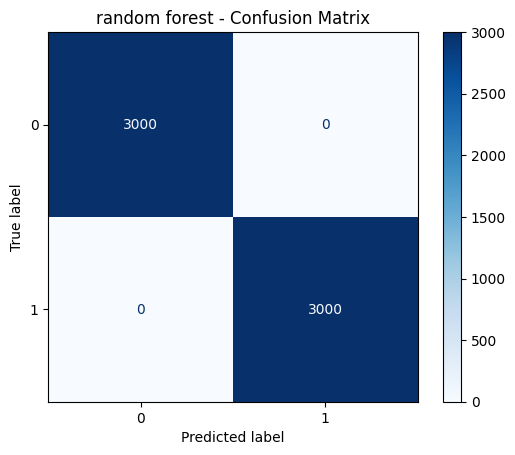

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("random forest - Confusion Matrix")
plt.show()

---